In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
h2dtfine = 0.005
h2dtcoarse = 0.01
hehdtfine = 0.004
hehdtcoarse = 0.01

In [3]:
import os

In [4]:
path = './perlgpu/finescale/'
files = os.listdir(path)

In [7]:
h2finedelays = np.arange(1, 33, dtype=np.int16) * 50
h2coarsedelays = np.arange(1, 21, dtype=np.int16) * 40
hehfinedelays = np.arange(1, 26, dtype=np.int16) * 50
hehcoarsedelays = np.arange(1, 21, dtype=np.int16) * 25

In [8]:
h2fine = np.zeros(32)
h2coarse = np.zeros(20)
hehfine = np.zeros(25)
hehcoarse = np.zeros(20)

for f in files:
    if f[-4:]!='.txt':
        continue
    x = f.split('_')
    mol = x[1]
    dt = float(x[3])
    delay = int(x[4])
    y = np.loadtxt(path + f, skiprows=2, delimiter=',')
    if mol=='h2':
        if dt==h2dtfine:
            j = np.where(h2finedelays==delay)[0]
            h2fine[j] = y[1]
        else:
            j = np.where(h2coarsedelays==delay)[0]
            h2coarse[j] = y[1]
    else:
        if dt==hehdtfine:
            j = np.where(hehfinedelays==delay)[0]
            hehfine[j] = y[1]
        else:
            j = np.where(hehcoarsedelays==delay)[0]
            hehcoarse[j] = y[1]

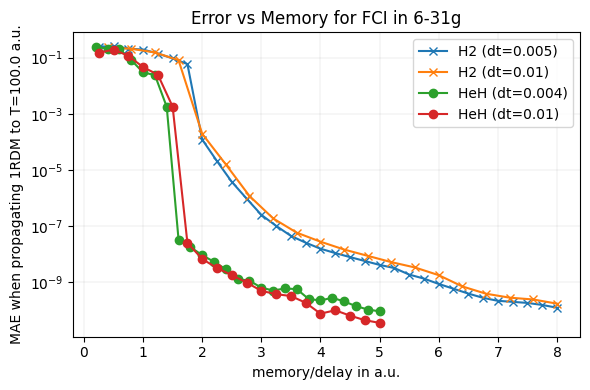

In [9]:
plt.figure(figsize=(6,4))
plt.semilogy(h2dtfine*h2finedelays, h2fine, label='H2 (dt=0.005)', marker='x')
plt.semilogy(h2dtcoarse*h2coarsedelays, h2coarse, label='H2 (dt=0.01)', marker='x')
plt.semilogy(hehdtfine*hehfinedelays, hehfine, label='HeH (dt=0.004)', marker='o')
plt.semilogy(hehdtcoarse*hehcoarsedelays, hehcoarse, label='HeH (dt=0.01)', marker='o')
plt.xlabel('memory/delay in a.u.')
plt.ylabel('MAE when propagating 1RDM to T=100.0 a.u.')
plt.title('Error vs Memory for FCI in 6-31g')
plt.legend()
plt.tight_layout()
plt.grid(True, color='grey', linewidth=0.1)
plt.savefig('dtinvarianceFCIFO.pdf')
plt.show()

# Field: amp=0.1, freq=E1-E0 gap, 5 cycles